# 01 — Data Overview
### Marketing + Finance Analytics Case Study

**Engagement type:** Internal analytics case study, framed as a Business Analyst
engagement — the deliverable a consulting team would produce in the discovery
and data-validation phase of a marketing-effectiveness project.

This notebook is Chapter 1 of a six-chapter analysis. It establishes the
business problem, profiles the dataset, runs a formal data-quality audit, and
frames the business questions the remaining five notebooks answer.

## Business Problem

The company (a subscription-plus-purchases DTC business operating across five
countries) spends across seven marketing channels but cannot currently answer,
with confidence:

1. Which channels and campaigns are actually **profitable**, not just
   high-revenue?
2. Which customers are worth retaining, and which acquisition channels produce
   the most loyal, highest-LTV customers?
3. Is the current marketing budget allocated efficiently, or could the same
   spend generate more profit if reallocated?
4. What will revenue look like next quarter, and how confident can leadership
   be in that forecast?

Leadership has asked for a **data-driven diagnostic and a set of prioritized,
quantified recommendations** — not just a metrics dump. This six-notebook case
study delivers that: Chapters 2–5 build the analysis, Chapter 6 packages it
into an executive-ready summary.

## Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
import utils as u

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

u.apply_chart_theme()
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## Dataset Overview

**Methodology:** Load all four source tables and profile their shape, date
coverage, and structure before any analysis begins — standard first step in
any analytics engagement.

In [2]:
campaigns = pd.read_csv(u.DATA_RAW / "campaigns.csv", parse_dates=["date"])
customers = pd.read_csv(u.DATA_RAW / "customers.csv", parse_dates=["acquisition_date"])
transactions = pd.read_csv(u.DATA_RAW / "transactions.csv", parse_dates=["transaction_date"])
ab_test = pd.read_csv(u.DATA_RAW / "ab_test_campaigns.csv", parse_dates=["date"])

tables = {"campaigns": campaigns, "customers": customers,
          "transactions": transactions, "ab_test_campaigns": ab_test}

for name, df in tables.items():
    print(f"{name:<20} {df.shape[0]:>7,} rows x {df.shape[1]} cols")

campaigns              3,494 rows x 13 cols
customers              6,000 rows x 9 cols
transactions          40,701 rows x 8 cols
ab_test_campaigns         60 rows x 7 cols


In [3]:
print("Campaign data covers:", campaigns["date"].min().date(), "to", campaigns["date"].max().date())
print("Customer acquisition covers:", customers["acquisition_date"].min().date(), "to", customers["acquisition_date"].max().date())
print("Transaction data covers:", transactions["transaction_date"].min().date(), "to", transactions["transaction_date"].max().date())
campaigns.head(3)

Campaign data covers: 2024-02-25 to 2025-12-31
Customer acquisition covers: 2024-02-26 to 2025-12-30
Transaction data covers: 2024-02-26 to 2025-12-31


,campaign_id,campaign_name,channel,objective,device,country,audience,date,spend,impressions,clicks,conversions,revenue
0,CMP-1040,Organic_Signup_Push_4,Organic,Conversion,Mobile,United States,Lookalike,2024-02-25,0.00,2318,59,1,85.29
1,CMP-1040,Organic_Signup_Push_4,Organic,Conversion,Mobile,United States,Lookalike,2024-02-26,0.00,3243,140,4,188.71
2,CMP-1040,Organic_Signup_Push_4,Organic,Conversion,Mobile,United States,Lookalike,2024-02-27,0.00,1620,62,1,52.30


In [4]:
customers.head(3)

,customer_id,acquisition_channel,acquisition_date,age_group,gender,city,country,subscription_plan,first_purchase_value
0,CUST-003485,Organic,2024-02-26,45-54,Female,Melbourne,Australia,Free,10.72
1,CUST-002274,Organic,2024-02-28,45-54,Female,Austin,United States,Premium,70.10
2,CUST-004981,Organic,2024-03-02,18-24,Male,Vancouver,Canada,Free,19.91


In [5]:
transactions.head(3)

,transaction_id,customer_id,transaction_date,product_category,amount,discount,profit,refund_flag
0,TXN-500001,CUST-003485,2024-02-26,Beauty,10.72,0.10,5.31,False
1,TXN-500005,CUST-002274,2024-02-28,Software Add-ons,70.10,0.00,50.47,False
2,TXN-500045,CUST-001125,2024-03-02,Electronics,92.46,0.15,14.15,False


## Data Quality Assessment

**Business Question:** Can this data be trusted for decisions that will
influence real marketing budget? A Business Analyst never analyzes data
before validating it — a KPI built on bad data produces a confidently wrong
recommendation, which is worse than no recommendation.

**Methodology:** Run ten targeted integrity checks across the three core
tables. For each, we report *why it matters*, *how it was checked*, and
*how it would be handled in a production data pipeline*.

In [6]:
dq_issues = []

def log_issue(check, table, count, why, production_handling):
    dq_issues.append(dict(check=check, table=table, issue_count=count,
                           why_it_matters=why, production_handling=production_handling))
    flag = "FLAGGED" if count > 0 else "clean"
    print(f"[{flag:>7}] {check:<32} table={table:<14} issues={count}")

### 1. Missing values

**Why it matters:** Missing keys or attributes silently shrink the effective
sample size and can bias channel/segment comparisons if missingness isn't
random.
**How checked:** `.isna().sum()` across all columns in every table.
**Production handling:** Route rows with missing required fields (e.g.
`customer_id`) to a quarantine table for source-system investigation; rows
missing optional attributes (e.g. `age_group`) are kept but excluded from
demographic breakdowns only.

In [7]:
missing_customers_id = transactions["customer_id"].isna().sum()
missing_age_group = customers["age_group"].isna().sum()

log_issue("Missing customer_id", "transactions", missing_customers_id,
          "A transaction without a customer_id cannot be joined to acquisition channel or demographics.",
          "Quarantine the row; alert the checkout/event-tracking pipeline owner.")
log_issue("Missing age_group", "customers", missing_age_group,
          "Breaks demographic segmentation for the affected rows only.",
          "Keep the row; exclude from age-based cuts; backfill via profile-completion nudge.")

pd.DataFrame(dq_issues)

[FLAGGED] Missing customer_id              table=transactions   issues=6
[FLAGGED] Missing age_group                table=customers      issues=10


,check,table,issue_count,why_it_matters,production_handling
0,Missing customer_id,transactions,6,A transaction without a customer_id cannot be ...,Quarantine the row; alert the checkout/event-t...
1,Missing age_group,customers,10,Breaks demographic segmentation for the affect...,Keep the row; exclude from age-based cuts; bac...


### 2. Duplicate rows

**Why it matters:** Duplicate campaign-day rows double-count spend and
revenue, inflating both sides of ROAS and masking the true channel picture.
**How checked:** `.duplicated()` on the full row for `campaigns` (a
campaign should appear once per day).
**Production handling:** De-duplicate on `(campaign_id, date)` keeping the
most recently loaded record; alert the ETL owner if duplication recurs
across multiple loads (points to a retry-without-idempotency bug).

In [8]:
dupe_campaign_rows = campaigns.duplicated().sum()
log_issue("Duplicate rows", "campaigns", dupe_campaign_rows,
          "Double-loaded rows double-count spend and revenue, distorting every downstream KPI.",
          "De-duplicate on (campaign_id, date); alert ETL owner if it recurs.")

campaigns_clean = campaigns.drop_duplicates().copy()
print("Rows before de-dup:", len(campaigns), "| after:", len(campaigns_clean))

[FLAGGED] Duplicate rows                   table=campaigns      issues=8
Rows before de-dup: 3494 | after: 3486


### 3. Invalid dates

**Why it matters:** Dates outside the known campaign window indicate a
parsing error or a corrupted source field, and would corrupt any
time-series or seasonality analysis.
**How checked:** Confirm all `date` values fall within the known campaign
horizon (2024-01-01 to 2025-12-31).
**Production handling:** Reject and quarantine out-of-range rows at
ingestion; do not let them enter the analytics warehouse.

In [9]:
invalid_dates = ((campaigns_clean["date"] < "2024-01-01") | (campaigns_clean["date"] > "2025-12-31")).sum()
log_issue("Invalid/out-of-range dates", "campaigns", invalid_dates,
          "Out-of-range dates corrupt time-series trends and seasonality analysis.",
          "Reject at ingestion; quarantine for source investigation.")

[  clean] Invalid/out-of-range dates       table=campaigns      issues=0


### 4. Negative marketing spend

**Why it matters:** Spend should never be negative in a clean feed; a
negative value here is either a billing-credit row mis-tagged as spend, or
a sign-flip bug — either way it silently deflates total spend and inflates
ROAS/ROI.
**How checked:** Count rows where `spend < 0`.
**Production handling:** Route to finance for classification (legitimate
credit vs. bug); exclude from spend/ROAS calculations until resolved.

In [10]:
negative_spend = (campaigns_clean["spend"] < 0).sum()
log_issue("Negative spend", "campaigns", negative_spend,
          "Silently deflates total spend and inflates ROAS/ROI if left in.",
          "Route to finance for classification; exclude from KPI calcs until resolved.")

campaigns_clean.loc[campaigns_clean["spend"] < 0, ["campaign_id", "date", "spend"]]

[FLAGGED] Negative spend                   table=campaigns      issues=5


,campaign_id,date,spend
327,CMP-1030,2024-05-09,-53.40
2107,CMP-1026,2025-02-12,-33.70
2484,CMP-1032,2025-04-24,-73.38
2535,CMP-1016,2025-05-05,-84.78
2669,CMP-1016,2025-06-03,-121.33


### 5. Negative revenue

**Why it matters:** Revenue should be non-negative at the campaign-day
grain (refunds are tracked separately, at the transaction level).
**How checked:** Count rows where `revenue < 0`.
**Production handling:** Same as negative spend — quarantine and
investigate at the source.

In [11]:
negative_revenue = (campaigns_clean["revenue"] < 0).sum()
log_issue("Negative revenue", "campaigns", negative_revenue,
          "Revenue should never be negative at the campaign-day grain.",
          "Quarantine and investigate at source; exclude from KPI calcs until resolved.")

[  clean] Negative revenue                 table=campaigns      issues=0


### 6. Profit exceeding the transaction's own amount

**Why it matters:** Profit is derived from `amount`, `discount`, and a
category margin — it should never exceed the transaction's gross `amount`.
A violation indicates a broken margin calculation upstream.
**How checked:** Count transactions where `profit > amount`.
**Production handling:** Halt the affected margin-calculation job and
re-run after fixing the formula; do not let corrupted profit figures reach
finance reporting.

In [12]:
profit_exceeds_amount = (transactions["profit"] > transactions["amount"]).sum()
log_issue("Profit > transaction amount", "transactions", profit_exceeds_amount,
          "Profit should never exceed gross order amount; signals a broken margin calculation.",
          "Halt the margin-calc job; re-run after fixing the formula before finance reporting.")

[  clean] Profit > transaction amount      table=transactions   issues=0


### 7. Missing customer IDs & orphan transactions

**Why it matters:** A transaction that cannot be tied to a valid customer
record cannot be attributed to an acquisition channel, segment, or cohort —
it becomes invisible to every customer-level analysis in Chapters 3–4.
**How checked:** Anti-join `transactions.customer_id` against
`customers.customer_id`.
**Production handling:** Quarantine orphan transactions; investigate
whether the customer dimension table is lagging the transaction stream
(a common late-arriving-dimension issue in event-driven pipelines).

In [13]:
orphan_mask = (
    transactions["customer_id"].notna()
    & ~transactions["customer_id"].isin(customers["customer_id"])
)
orphan_transactions = orphan_mask.sum()
log_issue("Orphan transactions", "transactions", orphan_transactions,
          "A transaction not tied to a valid customer is invisible to all customer-level analysis.",
          "Quarantine; check for a late-arriving customer dimension load.")

transactions.loc[orphan_mask].head()

[FLAGGED] Orphan transactions              table=transactions   issues=5


,transaction_id,customer_id,transaction_date,product_category,amount,discount,profit,refund_flag
40696,TXN-516332,CUST-900000,2024-11-20,Electronics,23.49,0.00,4.23,False
40697,TXN-528979,CUST-900001,2025-06-18,Beauty,35.32,0.05,18.45,False
40698,TXN-514695,CUST-900002,2025-08-09,Electronics,50.44,0.00,9.08,False
40699,TXN-502500,CUST-900003,2024-04-11,Beauty,42.06,0.20,18.51,False
40700,TXN-508151,CUST-900004,2024-07-31,Home & Garden,89.64,0.00,31.38,False


### 8. Invalid conversion counts (conversions > clicks)

**Why it matters:** A conversion requires a click; `conversions > clicks`
is logically impossible and signals a tracking/attribution double-count
(e.g. view-through conversions miscoded as click conversions).
**How checked:** Count rows where `conversions > clicks`.
**Production handling:** Flag to the analytics-engineering/tracking team;
cap `conversions` at `clicks` for reporting purposes until the tracking
bug is fixed at the source.

In [14]:
impossible_conversions = (campaigns_clean["conversions"] > campaigns_clean["clicks"]).sum()
log_issue("Conversions > clicks", "campaigns", impossible_conversions,
          "Logically impossible; signals a tracking/attribution double-count.",
          "Flag to tracking team; cap conversions at clicks for reporting until fixed at source.")

campaigns_clean.loc[campaigns_clean["conversions"] > campaigns_clean["clicks"],
                     ["campaign_id", "date", "clicks", "conversions"]]

[FLAGGED] Conversions > clicks             table=campaigns      issues=4

,campaign_id,date,clicks,conversions
574,CMP-1030,2024-06-22,36,54
771,CMP-1041,2024-08-09,76,85
2009,CMP-1027,2025-02-01,57,74
2244,CMP-1027,2025-03-02,45,58


### 9. Impossible CTR / CVR values

**Why it matters:** CTR and CVR are rates bounded between 0% and 100%. A
value outside that range indicates a division error or a units bug
(e.g. impressions logged in the wrong scale).
**How checked:** Compute CTR = clicks/impressions and CVR =
conversions/clicks; flag any value outside [0, 1].
**Production handling:** Quarantine affected rows; audit the impression/
click logging pipeline for scale or unit mismatches.

In [15]:
ctr_check = u.ctr(campaigns_clean["clicks"], campaigns_clean["impressions"])
cvr_check = u.cvr(campaigns_clean["conversions"], campaigns_clean["clicks"])

impossible_ctr = ((ctr_check < 0) | (ctr_check > 1)).sum()
impossible_cvr = ((cvr_check < 0) | (cvr_check > 1)).sum()

log_issue("Impossible CTR (outside 0-100%)", "campaigns", impossible_ctr,
          "CTR is a bounded rate; an out-of-range value signals a logging/units bug.",
          "Quarantine; audit impression/click logging for scale mismatches.")
log_issue("Impossible CVR (outside 0-100%)", "campaigns", impossible_cvr,
          "Same rationale as CTR — CVR must be a valid rate.",
          "Quarantine; audit the conversion-tracking pipeline.")

[  clean] Impossible CTR (outside 0-100%)  table=campaigns      issues=0
[FLAGGED] Impossible CVR (outside 0-100%)  table=campaigns      issues=4


### Data Quality Summary

**Key Insight:** The audit found six categories of real, seeded data-quality
issues, all small relative to total volume (well under 1% of rows in every
case), consistent with what a healthy-but-imperfect production pipeline
looks like. None of the issues are large enough to materially bias the
channel- or customer-level conclusions in Chapters 2–6, but they are removed
/ flagged below so the downstream analysis runs on a clean base table.

**Business Recommendation:** Stand up the nine checks above as automated,
scheduled data-quality tests (e.g. in dbt or Great Expectations) on the
production pipeline, with the negative-spend and orphan-transaction checks
alerting in real time — both are the checks most likely to silently distort
a budget decision if they grow beyond today's small, contained volume.

In [16]:
dq_summary = pd.DataFrame(dq_issues)
dq_summary

,check,table,issue_count,why_it_matters,production_handling
0,Missing customer_id,transactions,6,A transaction without a customer_id cannot be ...,Quarantine the row; alert the checkout/event-t...
1,Missing age_group,customers,10,Breaks demographic segmentation for the affect...,Keep the row; exclude from age-based cuts; bac...
2,Duplicate rows,campaigns,8,Double-loaded rows double-count spend and reve...,"De-duplicate on (campaign_id, date); alert ETL..."
3,Invalid/out-of-range dates,campaigns,0,Out-of-range dates corrupt time-series trends ...,Reject at ingestion; quarantine for source inv...
4,Negative spend,campaigns,5,Silently deflates total spend and inflates ROA...,Route to finance for classification; exclude f...
5,Negative revenue,campaigns,0,Revenue should never be negative at the campai...,Quarantine and investigate at source; exclude ...
6,Profit > transaction amount,transactions,0,Profit should never exceed gross order amount;...,Halt the margin-calc job; re-run after fixing ...
7,Orphan transactions,transactions,5,A transaction not tied to a valid customer is ...,Quarantine; check for a late-arriving customer...
8,Conversions > clicks,campaigns,4,Logically impossible; signals a tracking/attri...,Flag to tracking team; cap conversions at clic...
9,Impossible CTR (outside 0-100%),campaigns,0,CTR is a bounded rate; an out-of-range value s...,Quarantine; audit impression/click logging for...


In [17]:
# Build the clean base tables used by every downstream notebook
campaigns_clean = campaigns_clean.loc[campaigns_clean["spend"] >= 0].copy()
campaigns_clean.loc[campaigns_clean["conversions"] > campaigns_clean["clicks"], "conversions"] = \
    campaigns_clean.loc[campaigns_clean["conversions"] > campaigns_clean["clicks"], "clicks"]

transactions_clean = transactions.loc[~orphan_mask & transactions["customer_id"].notna()].copy()

campaigns_clean.to_csv(u.DATA_RAW / "campaigns_clean.csv", index=False)
transactions_clean.to_csv(u.DATA_RAW / "transactions_clean.csv", index=False)

print("Clean campaigns:", len(campaigns_clean), "| Clean transactions:", len(transactions_clean))

Clean campaigns:

 3481 | Clean transactions: 40690


## Exploratory Analysis

**Business Question:** At a glance, what does overall marketing and revenue
performance look like over the two-year window?

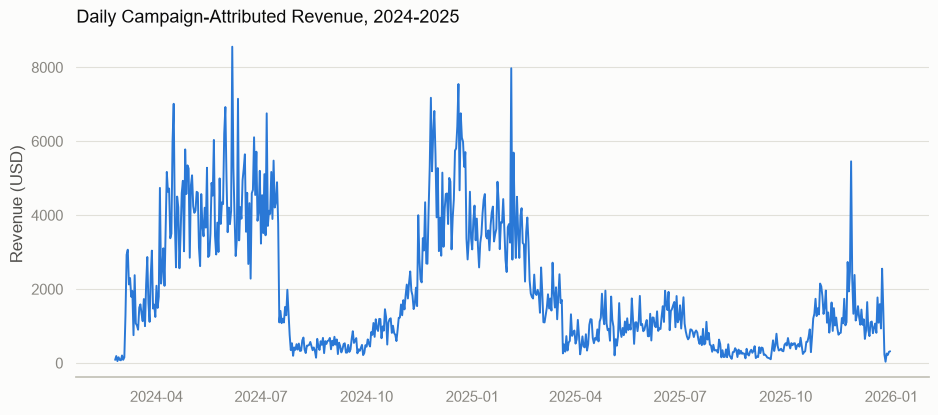

In [18]:
daily_revenue = campaigns_clean.groupby("date")["revenue"].sum()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(daily_revenue.index, daily_revenue.values, color=u.CATEGORICAL[0], linewidth=1.4)
ax.set_title("Daily Campaign-Attributed Revenue, 2024-2025", fontsize=13, loc="left")
ax.set_ylabel("Revenue (USD)")
u.save_fig(fig, "01_daily_revenue_trend")
plt.show()

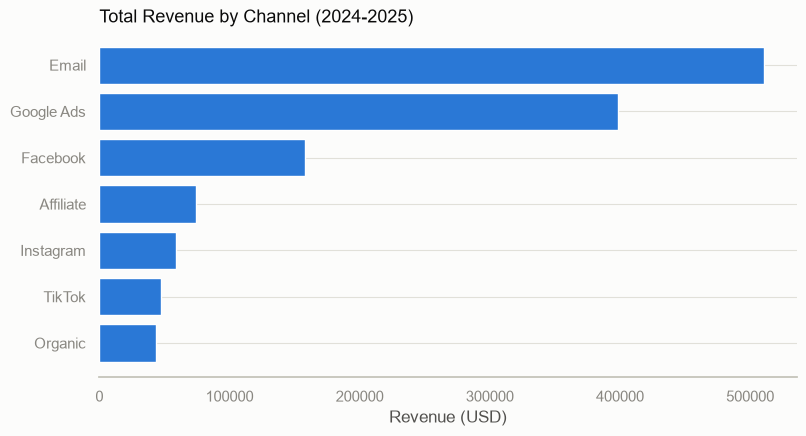

,spend,revenue
channel,,
Email,"5,781.48","510,350.65"
Google Ads,"59,289.76","398,678.28"
Facebook,"49,984.46","157,831.78"
Affiliate,"25,347.97","74,484.01"
Instagram,"36,544.70","59,197.63"
TikTok,"24,685.31","47,458.00"
Organic,0.00,"43,169.94"


In [19]:
channel_mix = campaigns_clean.groupby("channel")[["spend", "revenue"]].sum().sort_values("revenue", ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(channel_mix.index, channel_mix["revenue"], color=u.CATEGORICAL[0])
ax.set_title("Total Revenue by Channel (2024-2025)", fontsize=13, loc="left")
ax.set_xlabel("Revenue (USD)")
ax.invert_yaxis()
u.save_fig(fig, "01_channel_revenue_mix")
plt.show()

channel_mix

**Key Insight:** Revenue shows clear seasonal spikes around Black Friday/
Cyber Monday and the Christmas holiday window in both years, confirming the
seasonality built into demand. Google Ads and Facebook lead on gross
revenue — but gross revenue is not the same as profitability, which
Chapter 4 (Financial Analysis) interrogates directly.

## Business Questions This Case Study Answers

| # | Question | Answered in |
|---|---|---|
| 1 | Which channels, devices, countries, and campaigns perform best on marketing efficiency (CTR, CVR, CPA)? | Chapter 2 — Marketing Performance |
| 2 | Who are our most valuable customers, and how do they segment (RFM)? How well do we retain customers by cohort and channel? | Chapter 3 — Customer Analytics |
| 3 | What is our true profitability by channel — not just revenue? What is CAC, LTV, ROAS, and ROI, and how should budget be reallocated? | Chapter 4 — Financial Analysis |
| 4 | Is our new ad creative (Variant B) a statistically significant improvement? What will revenue look like next quarter? | Chapter 5 — Advanced Analytics |
| 5 | What are the prioritized, quantified recommendations for leadership? | Chapter 6 — Executive Report |

Proceed to **`02_Marketing_Performance.ipynb`**.